# Data generation

This notebook presents the pipeline to gnerate the synthetic datasets used to train and validate the CNN model.

In [2]:
from gen_functions import *
from tqdm import tqdm
import numpy as np
import os as os
import matplotlib.pyplot as plt
import astropy.cosmology as astr_cosm
import pandas as pd

import pycbc.detector as pycbc_det
import pycbc.psd as pycbc_psd
import pycbc.filter as pycbc_fil
import pycbc.catalog

# import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
root_dir = '/data/gvolpi'
base_dir = os.path.join(root_dir, 'data')


# create folder to store everything
if not os.path.exists(base_dir):
    os.mkdir(base_dir)

I use this function to define the priors from which the intrinsic and extrinsic parameters are drawn from. 

As intrinsic parameters to generate the GW template I consider the two components **masses**, the two components dimensionless **spins**, the **luminosity distance** to the source (input to the function is in Mpc) and the **inclination** angle between the angular orbital momentum of the inspiral and the line of sight (input to the function is in radians). 

While as extrinsic parameters we have **RA** and **DEC**, identifying the sky position of the source. 

Chosen priors:
- $m_1 \sim \mathcal{U}(5,90) \ M_\odot$
- $m_2 \sim \mathcal{U}(5,90) \ M_\odot$
- $d_L \sim \mathcal{U}(200,5000) \ \textbf{Mpc}$
- $i \sim \mathcal{U}(0,\pi/2) \ \textbf{rad}$
- $\chi_1 \sim \mathcal{U}(-1,1)$
- $\chi_2 \sim \mathcal{U}(-1,1)$
- $RA \sim \mathcal{U}(0,2\pi) \ \textbf{rad}$
- $DEC \sim \mathcal{U}(0,\pi) \ \textbf{rad}$

Let's plot an example of a simulated signal and noise strain for the Virgo detector. 

In [5]:
m1 = 30
m2 = 30
dist = 1000
ra = np.pi
dec = np.pi / 2

sampling_freq = 4096
cut_off = 30

delta_t = 1.0 / sampling_freq
time_length = 4 # seconds of data
length = int(time_length / delta_t) 

delta_f = 1.0 / time_length  
flength = int(length / 2 + 1)

# define the detector's PSD
Virgo_PSD = pycbc_psd.analytical.AdvVirgo(flength, delta_f, low_freq_cutoff=15) 

In [8]:
# generate plus and cross polarization with SEOBNR approximant 
hp, hc = pycbc_wf.get_td_waveform(approximant = "SEOBNRv4_opt", mass1 = m1, mass2 = m2, 
                                  distance=dist, delta_t = 1.0 / sampling_freq, f_lower = cut_off)

# project the polarizations onto the detector 
signal = V1_gw(hp, hc, ra, dec)

# generate Gaussian noise following the detector PSD
noise = noise_gen(Virgo_PSD)

# insert the signal in the noise to get the raw strain
strain, t = injection_by_hand(noise, signal)

# calculate the SNR
snr = get_SNR(signal, strain, Virgo_PSD)
print(f'The SNR is: {snr:.1f}')

The SNR is: 21.5


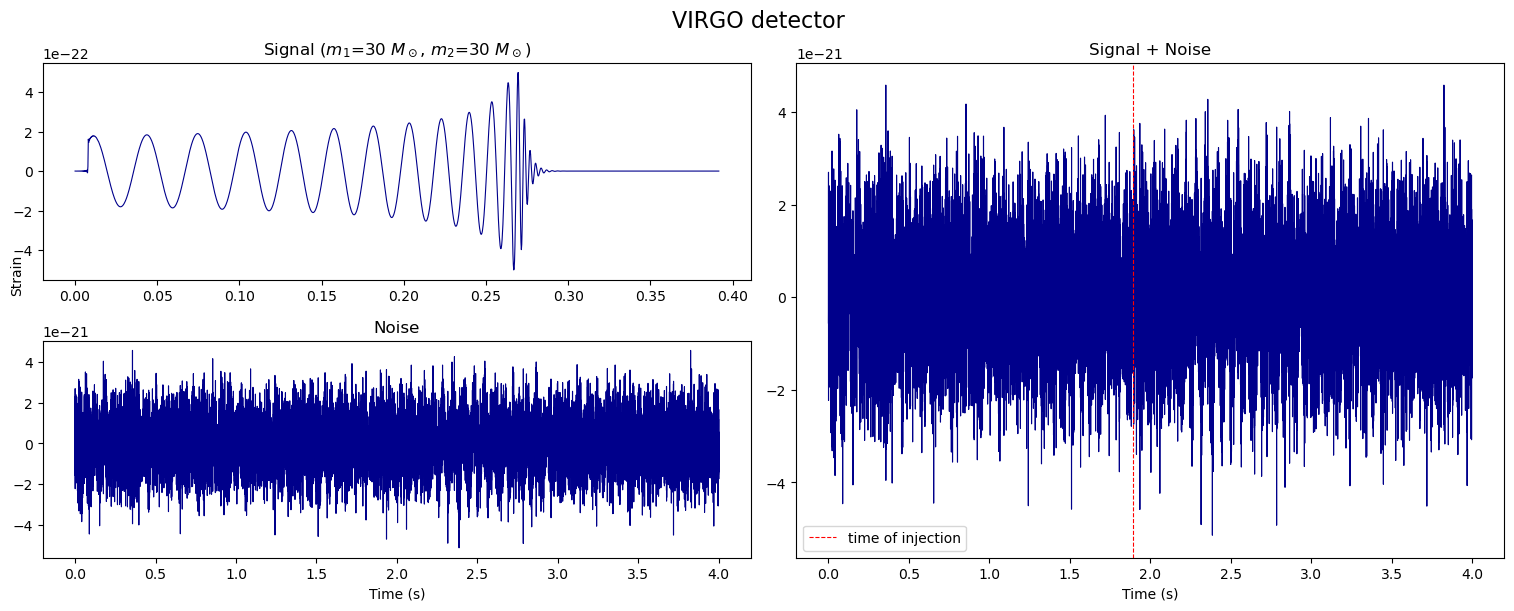

In [9]:
fig = plt.figure(figsize=(15, 6), constrained_layout=True)
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])   
ax3 = fig.add_subplot(gs[:, 1])  

ax1.set_title(fr'Signal ($m_1$={m1} $M_\odot$, $m_2$={m2} $M_\odot$)')
ax1.plot(np.array(signal.sample_times) + np.abs(min(np.array(signal.sample_times))), signal, 
         c='darkblue', linewidth=0.8)

ax2.set_title('Noise')
ax2.plot(noise.sample_times, noise, c='darkblue', linewidth=0.8)
ax2.set_xlabel('Time (s)')

ax3.set_title('Signal + Noise')
ax3.plot(strain.sample_times, strain, c='darkblue', linewidth=0.8)
ax3.axvline(t, color='red', linestyle='--', linewidth=0.8, label='time of injection')
ax3.legend()

fig.text(0.001, 0.55, 'Strain', va='center', rotation='vertical')
plt.suptitle('VIRGO detector', fontsize=16)
plt.xlabel('Time (s)')

plt.show()
plt.close()

Let's now plot the strain before and after the preprocessing steps.

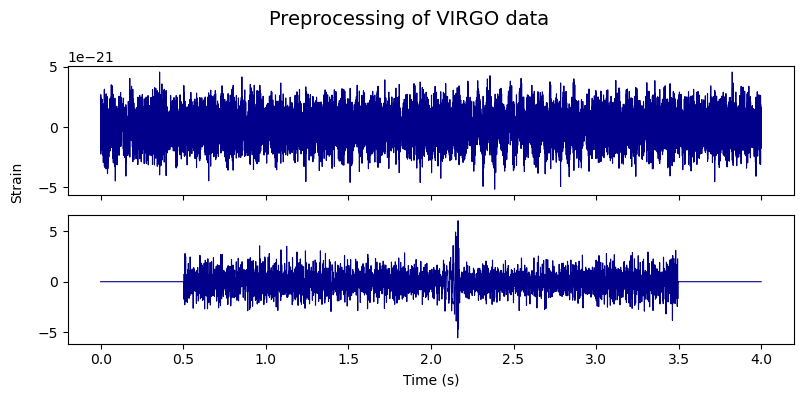

In [10]:
# preprocess the data 
data = pycbcty.timeseries.TimeSeries(process_data(strain), strain.delta_t)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(8, 4))
ax1.plot(strain.sample_times, strain, c='darkblue', linewidth=0.8)
ax2.plot(data.sample_times, data, c='darkblue', linewidth=0.8)
ax2.set_xlabel("Time (s)")
plt.suptitle('Preprocessing of VIRGO data', fontsize=14)
fig.text(0.001, 0.55, 'Strain', va='center', rotation='vertical')
plt.tight_layout()
plt.show()
plt.close()

The following function creates a bank of GW signals for the V1, H1 and L1 interferometers.
By specifying the number of samples, $n$ combinations of intrinsic and extrinsic parameters are drawn from the priors specified above. For each sample, the code generates a noise realization for each detector and inserts the GW signal to obtain the raw time series data. Time of flight between the different interferometers are taken into account. 
This function also calculates the network SNR and if it falls outside the [10,25] range it rescales the luminosity distance of the source, provided it remains in the [200, 5000] Mpc range. The data is then saved in an .npz file.  

In [5]:
def get_dataset(n):
    X, y = [], []
    
    # get params from priors for all the n samples 
    m1, m2, d, inc, z1, z2, ra, dec = get_params(n)

    headers = np.array([
        'mass 1', 'mass 2', 'spin 1', 'spin 2', 'SNR', 'distance (Mpc)',
        'inclination', 'ra', 'dec',
        'ligo merger time (sec)',
        'virgo merger time (sec)',
        'kagra merger time (sec)'
    ])

    for i in tqdm(range(n)):
        try:
            # fixed noise realization per sample
            noises = [noise_gen(Ligo_PSD), noise_gen(Ligo_PSD), noise_gen(Virgo_PSD)]

            current_d = d[i]
            valid_sample = False

            while True:
                # generate waveforms with current params 
                hp, hc = template(
                    m1[i], m2[i], z1[i], z2[i], inc[i], current_d
                )

                #### L1 (reference time) ####
                signal_L1 = L1_gw(hp, hc, ra[i], dec[i]) 
                strain_L1, t_L1 = injection_by_hand(noises[0], signal_L1)
                data_L1 = process_data(strain_L1)

                #### H1 ####
                t_H1 = t_L1 - L1.time_delay_from_detector(H1, ra[i], dec[i], t_L1)
                signal_H1 = H1_gw(hp, hc, ra[i], dec[i]) 
                strain_H1, _ = injection_by_hand(noises[1], signal_H1, t_inj=t_H1)
                data_H1 = process_data(strain_H1)

                ### V1 #### 
                t_V1 = t_L1 - L1.time_delay_from_detector(V1, ra[i], dec[i], t_L1)
                signal_V1 = V1_gw(hp, hc, ra[i], dec[i])  
                strain_V1, _ = injection_by_hand(noises[2], signal_V1, t_inj=t_V1) 
                data_V1 = process_data(strain_V1)

                # compute network SNR
                snr_L1 = get_SNR(signal_L1, strain_L1, Ligo_PSD)
                snr_H1 = get_SNR(signal_H1, strain_H1, Ligo_PSD)
                snr_V1 = get_SNR(signal_V1, strain_V1, Virgo_PSD)
                snr_value = np.sqrt(snr_L1**2 + snr_H1**2 + snr_V1**2)

                # if SNR is in range, exit from the loop and go to next sample 
                if 10 <= snr_value <= 25:
                    valid_sample=True
                    break

                # otherwise, scale the distance to get desired SNR
                target_snr = np.random.uniform(10, 25)
                current_d *= snr_value / target_snr

                # if the scaled distance is not valid, exit from the loop and go to next sample 
                if not (200 <= current_d <= 5000):
                    valid_sample=False
                    break 

            if valid_sample:
                X.append(np.stack([data_L1, data_H1, data_V1], axis=-1))
                y.append((
                    round(m1[i], 2), round(m2[i], 2),
                    round(z1[i], 2), round(z2[i], 2),
                    round(snr_value, 2), round(current_d, 2),
                    round(inc[i], 2), round(ra[i], 2), round(dec[i], 2),
                    round(t_L1, 2), round(t_H1, 2), round(t_V1, 2)
                ))

        except RuntimeError:
            print("Ringdown frequency > Nyquist frequency — skipping sample")
            continue
        except ValueError:
            print("Signal too long — skipping sample")
            continue

    return np.array(X), np.array(y), headers

Let's now generate the whole dataset.

In [6]:
N = 160_000 # desired number of samples 
chunk = 5_000  # size of each chunk

X_path = os.path.join(base_dir, "X_memmap.dat")
y_path = os.path.join(base_dir, "y_memmap.dat")
headers = None

# if a partial dataset is already present than load it, othwerwise start from scratch 
if os.path.exists(X_path) and os.path.exists(y_path):
    print("Memmap already exist.")

    X_mm = np.memmap(
        X_path,
        dtype="float32",
        mode="r+",
        shape=(N, 16384, 3)
    )

    y_mm = np.memmap(
        y_path,
        dtype="float32",
        mode="r+",
        shape=(N, 12)
    )

    nonzero_rows = np.any(y_mm != 0, axis=1)
    start = int(np.sum(nonzero_rows))

    print(f"Starting from start = {start}")

else:
    print("Memmap not found.")

    X_mm = np.memmap(
        X_path,
        dtype="float32",
        mode="w+",
        shape=(N, 16384, 3)
    )

    y_mm = np.memmap(
        y_path,
        dtype="float32",
        mode="w+",
        shape=(N, 12)
    )

    start = 0

while start < N:
    print(f"Generating chunk, start={start}")

    X_tmp, y_tmp, headers_tmp = get_dataset(chunk)

    if headers is None:
        headers = headers_tmp

    n_written = len(X_tmp) # sometimes some examples are descarded
    n_to_write = min(n_written, N - start)
        
    X_mm[start : start + n_to_write] = X_tmp[:n_to_write]
    y_mm[start : start + n_to_write] = y_tmp[:n_to_write]

    X_mm.flush()
    y_mm.flush()
    
    start += n_to_write
    
print("Dataset generation complete.")

Memmap already existing.
Starting from start = 140794
Generating chunk... start=140794


  1%|█▏                                                                                            | 61/5000 [00:17<17:06,  4.81it/s]

Signal too long — skipping sample


  4%|████                                                                                         | 218/5000 [00:58<16:55,  4.71it/s]

Signal too long — skipping sample


...

 79%|████████████████████████████████████████████████████████████████████████▊                   | 3957/5000 [16:49<03:47,  4.58it/s]

Signal too long — skipping sample


 85%|██████████████████████████████████████████████████████████████████████████████              | 4241/5000 [18:01<02:56,  4.30it/s]

Signal too long — skipping sample


100%|████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [21:10<00:00,  3.94it/s]


In [ ]:
np.savez(
    base_dir+'/train_data.npz',
    X=X_mm,
    y=y_mm,
    
    headers=headers
)

## Input distributions 

In [5]:
import numpy as np
import os as os
import matplotlib.pyplot as plt
import seaborn as sns

root_dir = '/data/gvolpi'
base_dir = os.path.join(root_dir, 'data')

In [6]:
with np.load(base_dir+'/train_data.npz', mmap_mode='r') as data:
    y = np.array(data['y'])
    
m1 = y[:,0]
m2 = y[:,1]
spin1 = y[:,2]
spin2 = y[:,3]
d = y[:,5]
i = y[:,6]
ra = y[:,7]
dec = y[:,8]

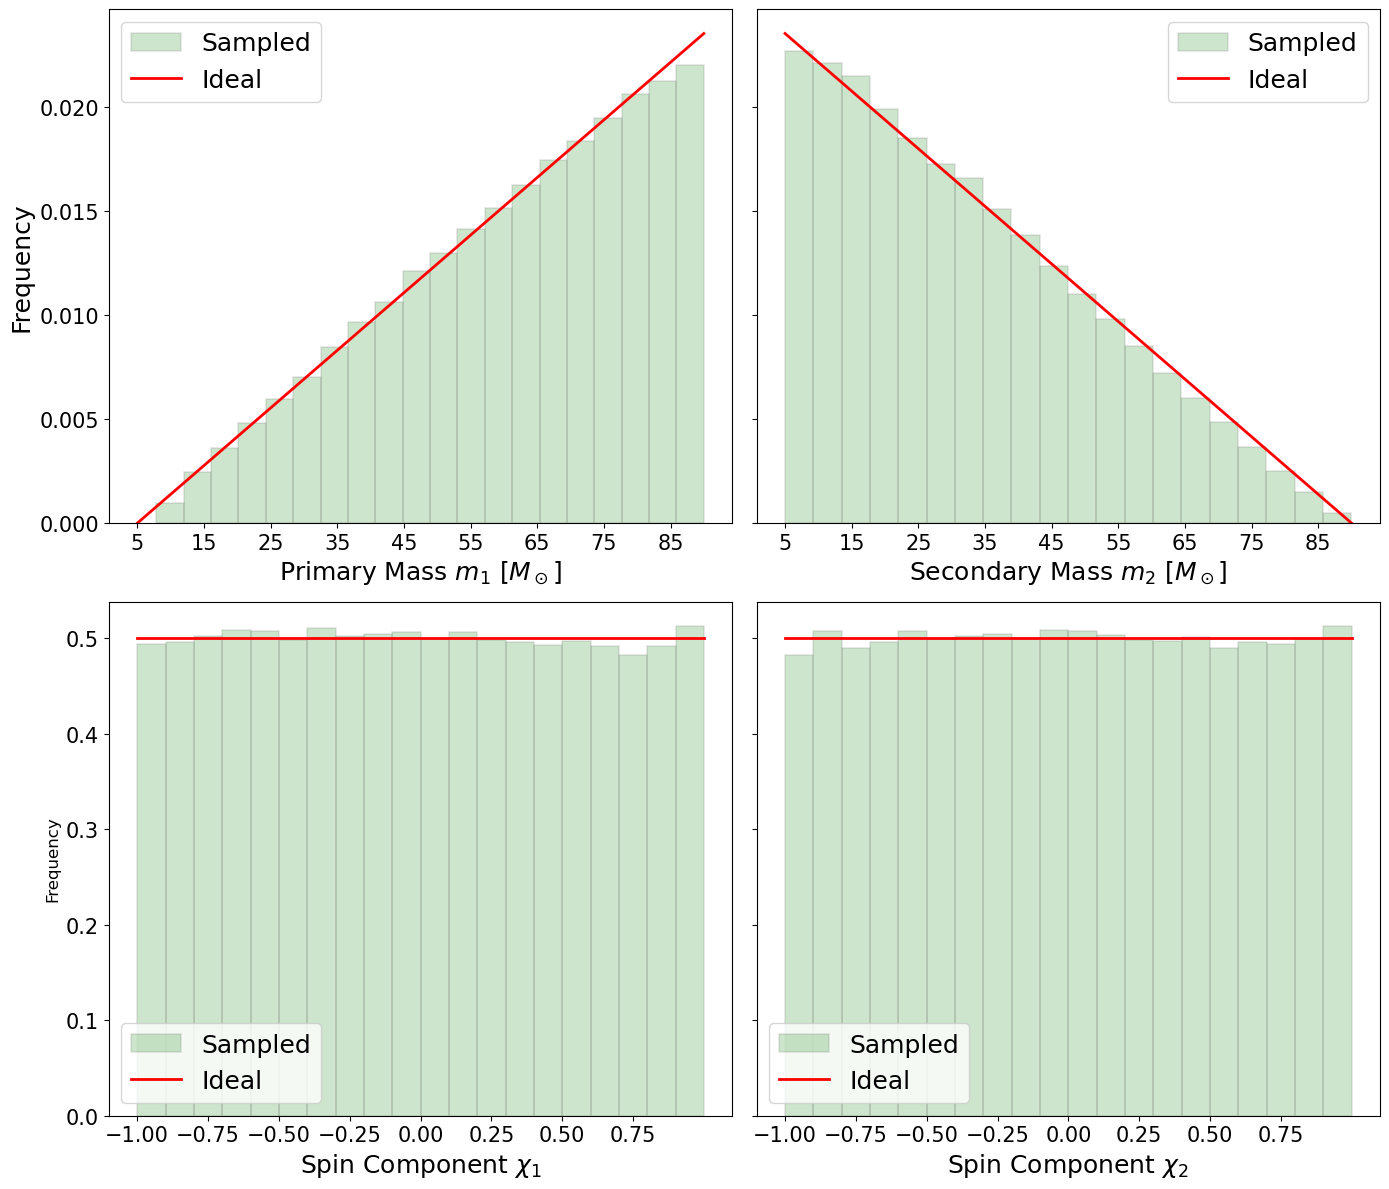

In [25]:
fig, ax = plt.subplots(nrows=2, ncols=2, sharey='row', figsize=(14, 12))

#### MASSES ####
M_MIN = 5.0
M_MAX = 90.0
m_ticks = np.arange(M_MIN, M_MAX, 10)

# ideal pdfs if m1 is forced to be greater than m2
def pdf_m1(x):
    return (2.0 / (M_MAX - M_MIN)**2) * (x - M_MIN) 

def pdf_m2(x):
    return (2.0 / (M_MAX - M_MIN)**2) * (M_MAX - x) 

plot_distribution(ax[0, 0], m1, r'Primary Mass $m_1$ [$M_\odot$]', (M_MIN, M_MAX), pdf_m1, x_ticks=m_ticks)
plot_distribution(ax[0, 1], m2, r'Secondary Mass $m_2$ [$M_\odot$]', (M_MIN, M_MAX), pdf_m2, x_ticks=m_ticks)
ax[0, 0].set_ylabel('Frequency', fontsize=18)

#### SPINS ####
Z_MIN = -1
Z_MAX = 1
x_ticks = np.arange(-1, 1, 0.25)

plot_distribution(ax[1, 0], spin1, r'Spin Component $\chi_1$', (Z_MIN, Z_MAX), x_ticks=x_ticks)
plot_distribution(ax[1,1], spin2, r'Spin Component $\chi_2$', (Z_MIN, Z_MAX), x_ticks=x_ticks)
ax[1, 0].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

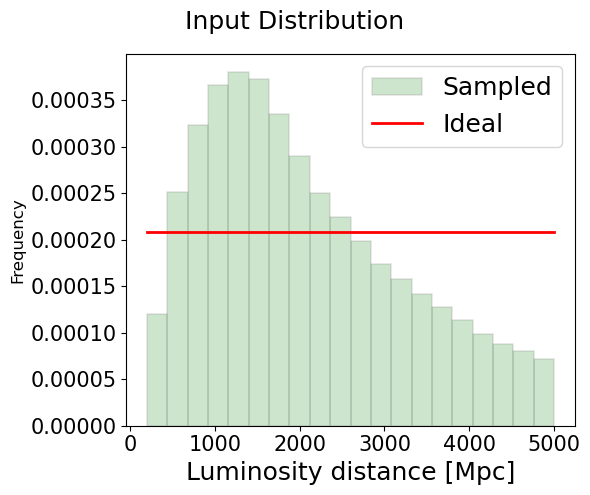

In [27]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharey='row', figsize=(6, 5))

#### DISTANCE ####
D_MIN = 200.0
D_MAX = 5000.0

plot_distribution(ax, d, r'Luminosity distance [Mpc]', (D_MIN, D_MAX))
ax.set_ylabel('Frequency', fontsize=12)

plt.suptitle('Input Distribution', fontsize=18)
plt.tight_layout()
plt.show()

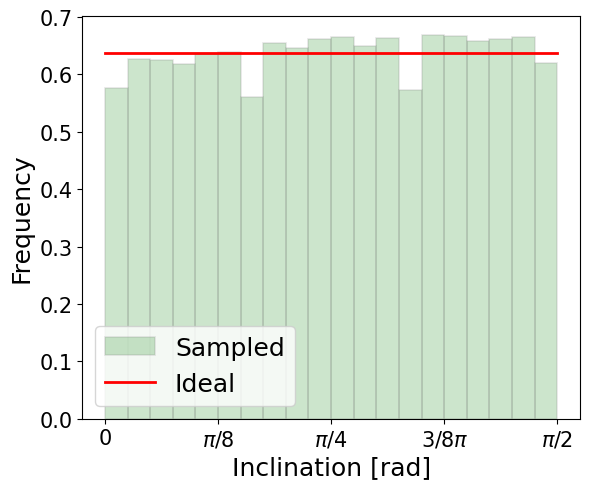

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharey='row', figsize=(6, 5))

#### INCLINATION ####
I_MIN = 0.0
I_MAX = np.pi/2
i_ticks = np.array([0, np.pi/8, np.pi/4, 3/8*np.pi, np.pi/2])
i_labels = [r'$0$', r'$\pi/8$', r'$\pi/4$', r'$3/8\pi$', r'$\pi/2$']

plot_distribution(ax, i, r'Inclination [rad]', (I_MIN, I_MAX), x_ticks=i_ticks, x_labels=i_labels)
ax.set_ylabel('Frequency', fontsize=18)

plt.tight_layout()
plt.show()

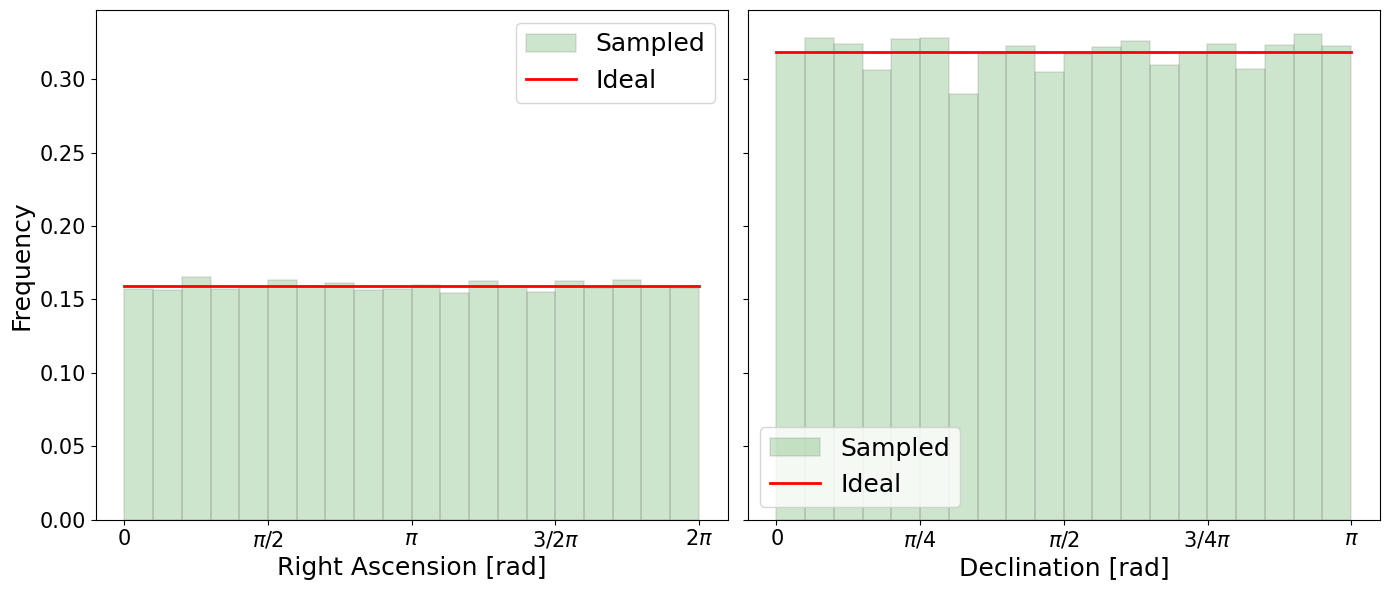

In [30]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharey='row', figsize=(14, 6))

#### right ascension
RA_MIN = 0.0
RA_MAX = 2 * np.pi
ra_ticks = np.array([0, np.pi/2, np.pi, np.pi*3/2, 2*np.pi])
ra_labels = [r'$0$', r'$\pi/2$', r'$\pi$', r'$3/2\pi$', r'$2\pi$']

plot_distribution(ax[0], ra, r'Right Ascension [rad]', (RA_MIN, RA_MAX), x_ticks=ra_ticks, x_labels=ra_labels)
ax[0].set_ylabel('Frequency', fontsize=18)

##### declination
DEC_MIN = 0.0
DEC_MAX = np.pi
dec_ticks = np.array([0, np.pi/4, np.pi/2, np.pi*3/4, np.pi])
dec_labels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3/4\pi$', r'$\pi$']

plot_distribution(ax[1], dec, r'Declination [rad]', (DEC_MIN, DEC_MAX), x_ticks=dec_ticks, x_labels=dec_labels)

plt.tight_layout()
plt.show()

Plots used in the thesis:

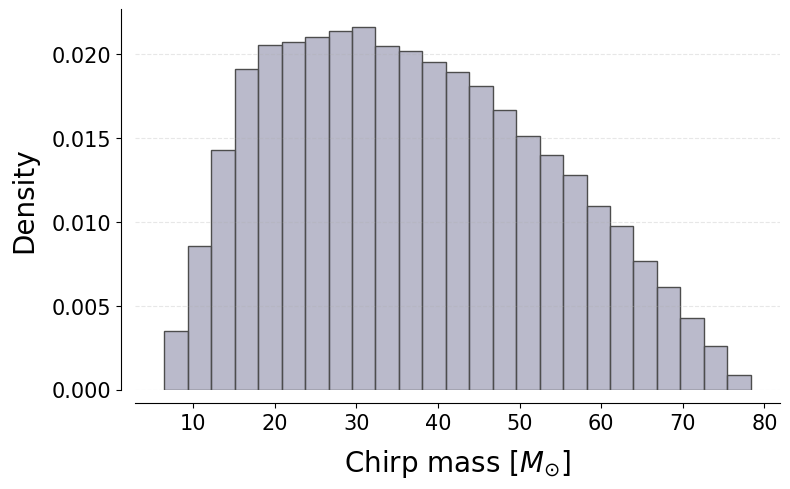

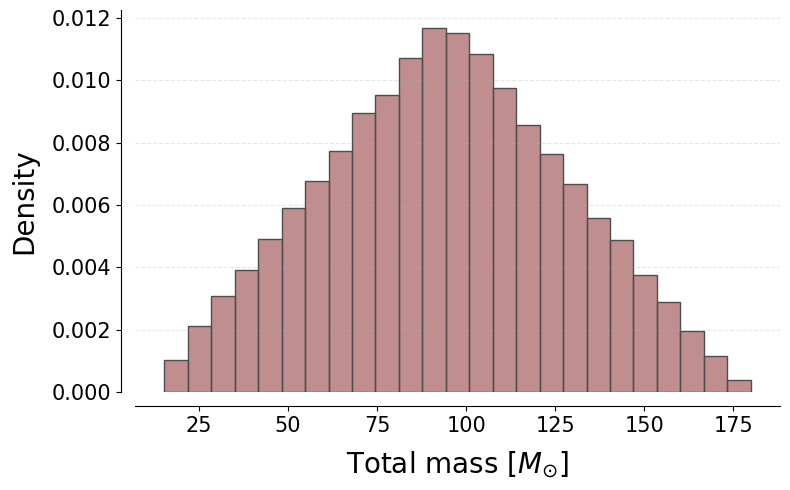

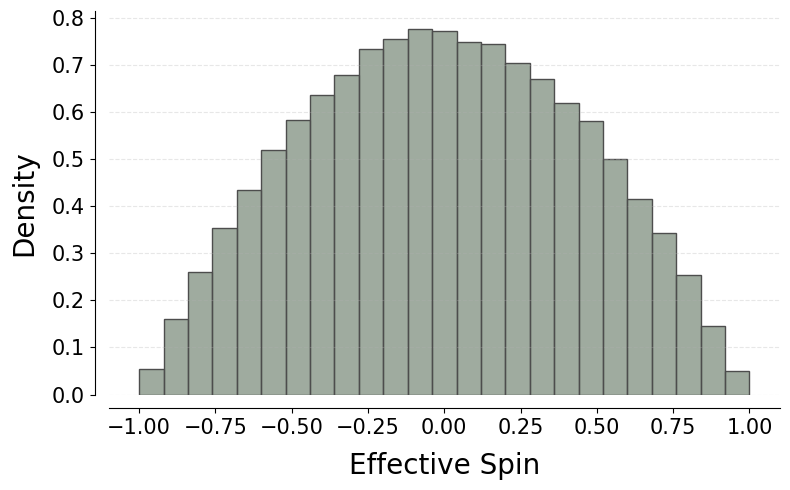

In [31]:
chi_eff = (m1*spin1 + m2*spin2) / (m1+m2)
m_chirp = ((m1*m2)**(3/5))/((m1+m2)**(1/5))
m_tot = m1 + m2

colors = ['#9D9DB6', '#A65E5E', '#778877']
param_names = ['Chirp mass', 'Total mass', 'Effective Spin']
labels = [r'Chirp mass $[M_{\odot}]$', r'Total mass $[M_{\odot}]$', 'Effective Spin']
data_list = [m_chirp, m_tot, chi_eff]

    
for i, data in enumerate(data_list):
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(
        data, 
        bins=25, 
        color=colors[i], 
        edgecolor='#4D4D4D',
        alpha=0.7,          
        stat="density",
        linewidth=1,
        ax=ax
    )

    ax.set_xlabel(labels[i], fontsize=20, labelpad=10)
    ax.set_ylabel('Density', fontsize=20, labelpad=10)
    
    ax.tick_params(axis='both', which='major', labelsize=15)

    ax.grid(axis='y', linestyle='--', alpha=0.3)
    sns.despine(ax=ax, offset=10)

    plt.tight_layout()
    plt.show()

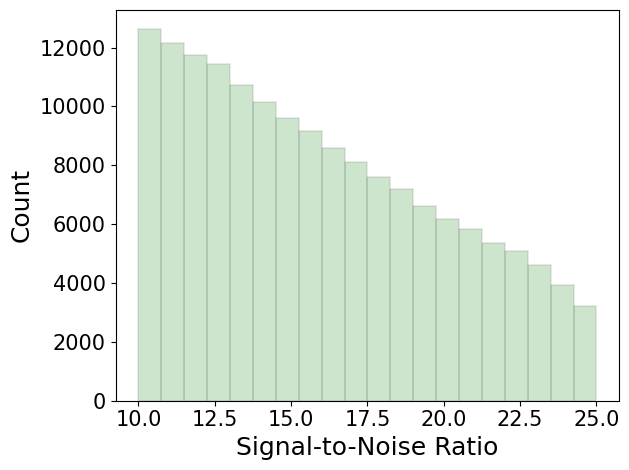

In [33]:
snr = y[:,4]

plt.hist(snr, bins=20, alpha=0.2, color='green', edgecolor='gray', linewidth=1.2)
plt.xlabel(r'Signal-to-Noise Ratio', fontsize=18)
plt.ylabel('Count', fontsize=18)

plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)

plt.tight_layout()
plt.show()

----------
# Real data

The following code is used to generate a dataset containing real GW data to validate the CNN performance. Selection criteria:

- Having a SNR in the [10,25] range
- Having estimated components' masses in the [5,90] range
- Being observed by L1, H1 and V1 interferometers

In [4]:
catalog_2 = pycbc.catalog.Catalog(source='gwtc-2.1')
catalog_3 = pycbc.catalog.Catalog(source='gwtc-3')
event_names = list(catalog_2.names) + list(catalog_3.names)

sample_rate = 4096
delta_t = 1.0 / sample_rate

X = []
y = []
names = []
masses = []

for name in event_names:

    event = pycbc.catalog.Merger(name)
    
    z = event.median1d('redshift')

    m1 = event.median1d('mass_1_source') * (1+z) # detector frame  
    m2 = event.median1d('mass_2_source') * (1+z) # detector frame  
    
    snr = event.median1d('network_matched_filter_snr')
    
    chirp_mass = np.array((event.median1d('chirp_mass_source_lower'),
                           event.median1d('chirp_mass_source'),
                           event.median1d('chirp_mass_source_upper'))) * (1+z) # detector frame
    
    tot_mass = np.array((event.median1d('total_mass_source_lower'),
                         event.median1d('total_mass_source'),
                         event.median1d('total_mass_source_upper'))) * (1+z) # detector frame 
    
    chi_eff = np.array((event.median1d('chi_eff_lower'),
                        event.median1d('chi_eff'),
                        event.median1d('chi_eff_upper')))
    
    if 5 < m1 < 90 and 5 < m2 < 90 and snr > 10:
        try:
            strain_L1 = event.strain('L1')
            strain_H1 = event.strain('H1')
            strain_V1 = event.strain('V1')     
        except ValueError:
            print(f"No strain data for {name}, skipping...")
            continue
            
        merger_time = event.time 
    
        # Process strain
        strain_L1 = pycbc.filter.resample_to_delta_t(strain_L1, delta_t)
        data_L1 = process_data(strain_L1.time_slice(merger_time - 2, merger_time + 2))
        
        strain_H1 = pycbc.filter.resample_to_delta_t(strain_H1, delta_t)
        data_H1 = process_data(strain_H1.time_slice(merger_time - 2, merger_time + 2))
        
        strain_V1 = pycbc.filter.resample_to_delta_t(strain_V1, delta_t)
        data_V1 = process_data(strain_V1.time_slice(merger_time - 2, merger_time + 2))

        X.append(np.stack([data_L1, data_H1, data_V1], axis=-1))
        y.append((chirp_mass, tot_mass, chi_eff))
        names.append(name)
        masses.append((m1,m2))
        
root_dir = '/data/gvolpi'
base_dir = os.path.join(root_dir, 'data')

np.savez(
    base_dir+'/inf_data.npz',
    X=X,
    y=y,
    names=names,
    masses=masses
)

No strain data for GW190910_112807-v2, skipping...
No strain data for GW190708_232457-v2, skipping...
No strain data for GW190707_093326-v2, skipping...
No strain data for GW190630_185205-v2, skipping...
No strain data for GW190620_030421-v2, skipping...
No strain data for GW190521_074359-v2, skipping...
No strain data for GW190421_213856-v2, skipping...
No strain data for GW170823-v2, skipping...
No strain data for GW170818-v2, skipping...
No strain data for GW170814-v4, skipping...
No strain data for GW170809-v2, skipping...
No strain data for GW170729-v2, skipping...
No strain data for GW170608-v4, skipping...
No strain data for GW170104-v3, skipping...
No strain data for GW151226-v3, skipping...
No strain data for GW150914-v4, skipping...
No strain data for GW200302_015811-v1, skipping...
No strain data for GW200225_060421-v1, skipping...
No strain data for GW200128_022011-v1, skipping...
No strain data for GW200112_155838-v1, skipping...
No strain data for GW191222_033537-v1, skip